In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Download CIFAR-10 (this auto-downloads to ./data/)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples: {len(trainset)}")
print(f"Test samples:     {len(testset)}")
print(f"Classes: {classes}")

100%|██████████| 170M/170M [00:09<00:00, 17.5MB/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data


/Users/marinoskermanos/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Training samples: 50000
Test samples:     10000
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


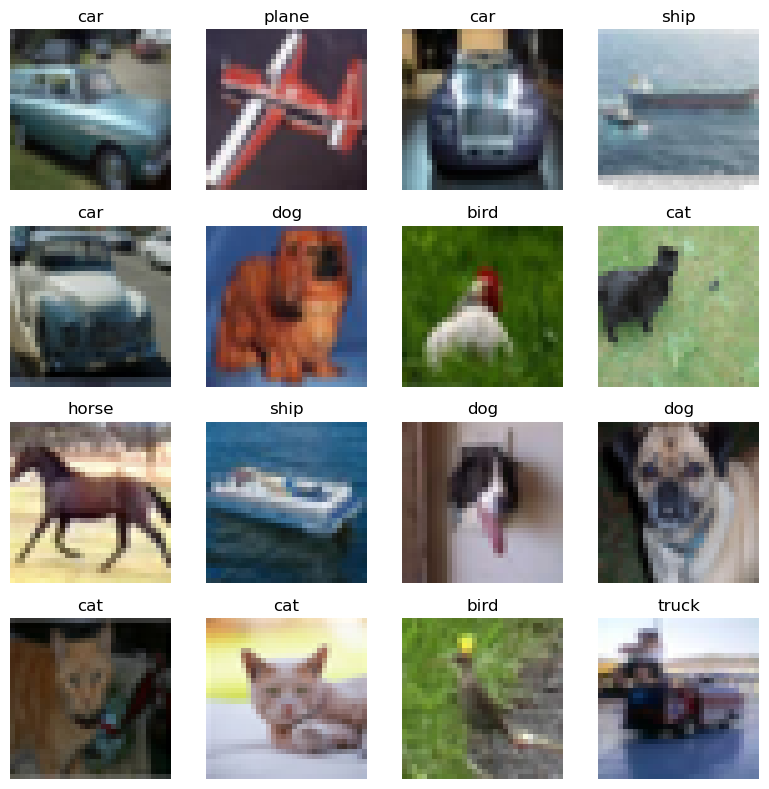

Sample grid saved to data/sample_grid.png


In [4]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Get a batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show 16 images in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.savefig('../data/sample_grid.png')
plt.show()
print("Sample grid saved to data/sample_grid.png")

In [5]:
from collections import Counter

label_counts = Counter(trainset.targets)
print("Class distribution (training set):")
for i, cls in enumerate(classes):
    print(f"  {cls:10s}: {label_counts[i]:,} samples")

# CIFAR-10 is perfectly balanced — 5,000 per class

Class distribution (training set):
  plane     : 5,000 samples
  car       : 5,000 samples
  bird      : 5,000 samples
  cat       : 5,000 samples
  deer      : 5,000 samples
  dog       : 5,000 samples
  frog      : 5,000 samples
  horse     : 5,000 samples
  ship      : 5,000 samples
  truck     : 5,000 samples
